Bu notebook, **HappyLlama** takımının kullanıcı oturumlarının değerini tahmin etmek için geliştirdiği çözümü içermektedir.

## İçindekiler
1. **Veri Yükleme ve Ön İşleme**
2. **Veri Keşfi ve Analizi** 
3. **Veri Önişleme ve Hazırlık**
4. **Özellik Mühendisliği**
5. **Veri Setini Hazırlama**
5. **Model Eğitimi ve CV**
6. **Tahmin ve Sonuç Üretimi**

## 0. Import ve Sabitler

**Apache Parquet**, big data analytics için tasarlanmış, yüksek verimliliğe sahip bir **columnar storage format** olup hızlı **query performance** ve daha düşük **storage costs** sağlar.

In [33]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Kaggle dizin yapısı
INPUT_DIR  = "/kaggle/input/competitions/datathon-2026"
OUTPUT_DIR = "/kaggle/working"

TRAIN_PATH  = f"{INPUT_DIR}/train.csv"
TEST_PATH   = f"{INPUT_DIR}/test_x.csv"

TRAIN_PARQUET = f"{OUTPUT_DIR}/train.parquet"
TEST_PARQUET  = f"{OUTPUT_DIR}/test.parquet"

## 1. Veri Yükleme ve Ön İşleme

In [34]:
train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

print(f"  train : {train_df.shape}  —  test : {test_df.shape}")

  train : (10000, 47)  —  test : (10000, 46)


### 1.1. Kategorik ve Sayısal Verilerin Ayrımı

Metni her ihtimale karşı standart hale geitrelim:

In [35]:
skip_cols = {'student_id', 'mentor_feedback_text'}
cat_cols = train_df.select_dtypes(include=['object']).columns

for col in cat_cols:
    if col not in skip_cols:
        train_df[col] = train_df[col].str.lower().str.strip()
        test_df[col] = test_df[col].str.lower().str.strip()

### 1.2. Format Dönüşümü ve Bellek Optimizasyonu

Yazdığımız reduce_mem_usage fonksiyonundaki df[col].astype('category') komutu ile metinleri arka planda sayılara çevirdik. Pandas artık "computer engineering" kelimesini bellekte metin olarak değil, örneğin 0 tam sayısı olarak tutuyor. Ancak bizim okuyabilmemiz için ekranda (veri setine baktığımızda) hala metin olarak gösteriyor. Bu adım sadece RAM'i rahatlatmak ve I/O hızını artırmak içindi.

In [36]:
def reduce_mem_usage(df):
    #orijinal veri setini yanlışlıkla bozmamak için
    df = df.copy()
    #İşleme başlamadan önce verinin RAM'de ne kadar yer kapladığını hesaplıyoruz.(MB) cinsi
    before = df.memory_usage(deep=True).sum() / 1024**2

    # Integer: Pandas en küçük uygun tipe indirir (int8 / int16 / int32)
    for col in df.select_dtypes('integer').columns:
        df[col] = pd.to_numeric(df[col], downcast='integer')

    # Float: NaN barındırsa bile Pandas float32'ye güvenle downcast yapar!
    for col in df.select_dtypes('float').columns:
        df[col] = pd.to_numeric(df[col], downcast='float')

    # Kategorik string sütunlar (ID ve NLP metinleri hariç)
    skip = {'student_id', 'mentor_feedback_text'}
    for col in df.select_dtypes('object').columns:
        if col not in skip:
            df[col] = df[col].astype('category')

    after = df.memory_usage(deep=True).sum() / 1024**2
    print(f"  {before:.1f} MB → {after:.1f} MB  ({100*(before-after)/before:.0f}% azaldı)")
    return df

print("[train]") ; train_df = reduce_mem_usage(train_df)
print("[test]")  ; test_df  = reduce_mem_usage(test_df)

[train]
  12.3 MB → 7.6 MB  (38% azaldı)
[test]
  12.2 MB → 7.6 MB  (38% azaldı)


In [37]:
train_df.to_parquet(TRAIN_PARQUET, index=False)
test_df.to_parquet(TEST_PARQUET,   index=False)

train_df = pd.read_parquet(TRAIN_PARQUET)
test_df  = pd.read_parquet(TEST_PARQUET)

print(f"train : {train_df.shape}  —  test : {test_df.shape}")

train : (10000, 47)  —  test : (10000, 46)


In [38]:
print("Train:")
train_df.head()

Train:


,student_id,application_year,age,graduation_year,department,university_tier,cgpa,english_exam_score,attendance_rate,failed_courses_count,...,leadership_score,presentation_score,certification_count,bootcamp_count,applications_sent,interviews_attended,hobby,preferred_social_media_platform,career_success_score,mentor_feedback_text
0,STU_000001,2021,21,2021,computer engineering,tier 4,3.17,62.540001,77.309998,0,...,62.700001,58.840000,3,1,24,0,photography,linkedin,86.779999,Proje kalitesi ve makine öğrenimi konusundaki ...
1,STU_000002,2024,20,2024,computer engineering,tier 4,3.24,75.099998,87.129997,3,...,42.320000,40.540001,2,0,46,5,reading,youtube,46.160000,Kodlama ve problem çözme becerileri gelişmekte...
2,STU_000003,2024,28,2024,electrical electronics engineering,tier 4,3.00,68.529999,95.639999,1,...,47.270000,82.559998,1,2,46,5,cinema,reddit,84.080002,İleri düzey frontend geliştirme becerileri ile...
3,STU_000004,2019,22,2018,computer engineering,tier 1,2.82,54.849998,77.800003,2,...,78.690002,85.050003,2,4,49,7,running,reddit,89.970001,Güçlü bir kodlama yeteneği ve backend geliştir...
4,STU_000005,2026,22,2026,computer engineering,tier 3,2.28,72.250000,71.970001,1,...,27.219999,84.290001,1,0,119,13,football,x,92.459999,Ürün analizi alanına olan tutkusu ve makine öğ...


In [39]:
print("Test:")
test_df.head()

Test:


,student_id,application_year,age,graduation_year,department,university_tier,cgpa,english_exam_score,attendance_rate,failed_courses_count,...,teamwork_score,leadership_score,presentation_score,certification_count,bootcamp_count,applications_sent,interviews_attended,hobby,preferred_social_media_platform,mentor_feedback_text
0,STU_010001,2025,23,2025,computer engineering,tier 4,2.59,45.270000,79.110001,2,...,90.019997,81.330002,30.540001,6,2,46,6,gaming,youtube,Öğrencinin proje çalışmasında dikkat çekici bi...
1,STU_010002,2023,23,2022,electrical electronics engineering,tier 3,3.12,66.300003,70.580002,1,...,82.779999,82.779999,42.369999,1,0,4,0,football,tiktok,"Bu öğrenci, problem çözme ve veri yapıları kon..."
2,STU_010003,2025,20,2025,computer engineering,tier 3,3.48,75.449997,67.930000,0,...,51.790001,63.299999,66.010002,4,1,66,3,cinema,instagram,Öğrencinin veri bilimi konusundaki ilgisi ve g...
3,STU_010004,2020,26,2019,software engineering,tier 2,2.92,45.580002,83.949997,0,...,90.889999,46.639999,82.599998,3,2,42,2,chess,linkedin,Son derece etkileyici bir başarıya imza atan b...
4,STU_010005,2024,21,2024,computer engineering,tier 3,2.85,63.080002,84.180000,1,...,42.779999,43.299999,39.650002,3,1,25,0,reading,tiktok,Öğrencinin yazılım geliştirme alanındaki çalış...


## 2. Veri Keşfi ve Analizi

In [40]:
# Kategorik ve kategorik olmayan sütunları ayıralım
categorical_cols = train_df.select_dtypes(include=['object', 'category']).columns
non_categorical_cols = train_df.select_dtypes(exclude=['object', 'category']).columns

print("--- KATEGORİK SÜTUNLAR VE TÜM EŞSİZ DEĞERLERİ ---")
for col in categorical_cols:
    unique_values = train_df[col].unique()
    print(f"\nSütun: {col} (Toplam {len(unique_values)} eşsiz değer)")
    print(unique_values)

print("\n" + "="*50 + "\n")

print("--- KATEGORİK OLMAYAN SÜTUNLARIN EŞSİZ DEĞER SAYISI ---")
for col in non_categorical_cols:
    unique_count = train_df[col].nunique()
    print(f"Sütun: {col} -> Eşsiz Değer Sayısı: {unique_count}")

--- KATEGORİK SÜTUNLAR VE TÜM EŞSİZ DEĞERLERİ ---

Sütun: student_id (Toplam 10000 eşsiz değer)
['STU_000001' 'STU_000002' 'STU_000003' ... 'STU_009998' 'STU_009999'
 'STU_010000']

Sütun: department (Toplam 7 eşsiz değer)
['computer engineering', 'electrical electronics engineering', 'management information systems', 'software engineering', 'statistics', 'mathematics', 'industrial engineering']
Categories (7, object): ['computer engineering', 'electrical electronics engineering', 'industrial engineering', 'management information systems', 'mathematics', 'software engineering', 'statistics']

Sütun: university_tier (Toplam 4 eşsiz değer)
['tier 4', 'tier 1', 'tier 3', 'tier 2']
Categories (4, object): ['tier 1', 'tier 2', 'tier 3', 'tier 4']

Sütun: target_role (Toplam 11 eşsiz değer)
['devops engineer', 'backend developer', 'frontend developer', 'product analyst', 'ai engineer', ..., 'software developer', 'data scientist', 'cloud engineer', 'cybersecurity analyst', 'mlops engineer']
L

1. Hedef Değişken (Career Success Score) Analizi


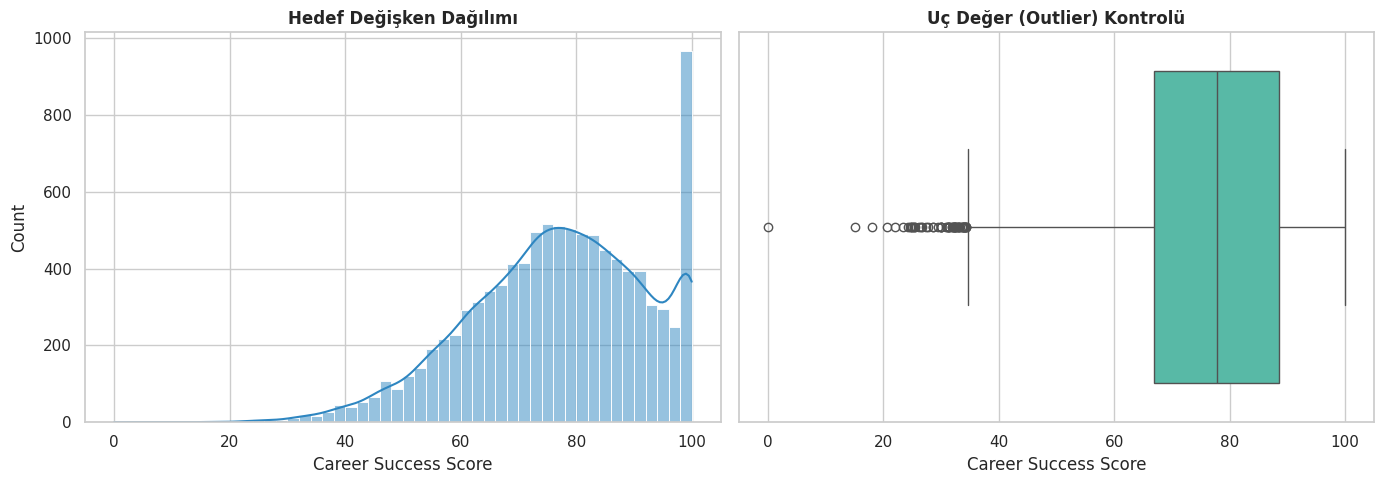

Hedef Değişken Çarpıklık (Skewness) Değeri: -0.451
Not: Dağılım nispeten normal, regresyon modelleri doğrudan uygulanabilir.


2. Eksik Veri (Missing Value) Matrisi
                                Eksik_Sayısı  Eksik_Oranı(%)
internship_duration_months              1657           16.57
english_exam_score                       953            9.53
github_avg_stars                         910            9.10
open_source_contribution_count           910            9.10
hr_interview_score                       780            7.80
linkedin_profile_score                   668            6.68
portfolio_score                          364            3.64


<Figure size 1000x400 with 0 Axes>

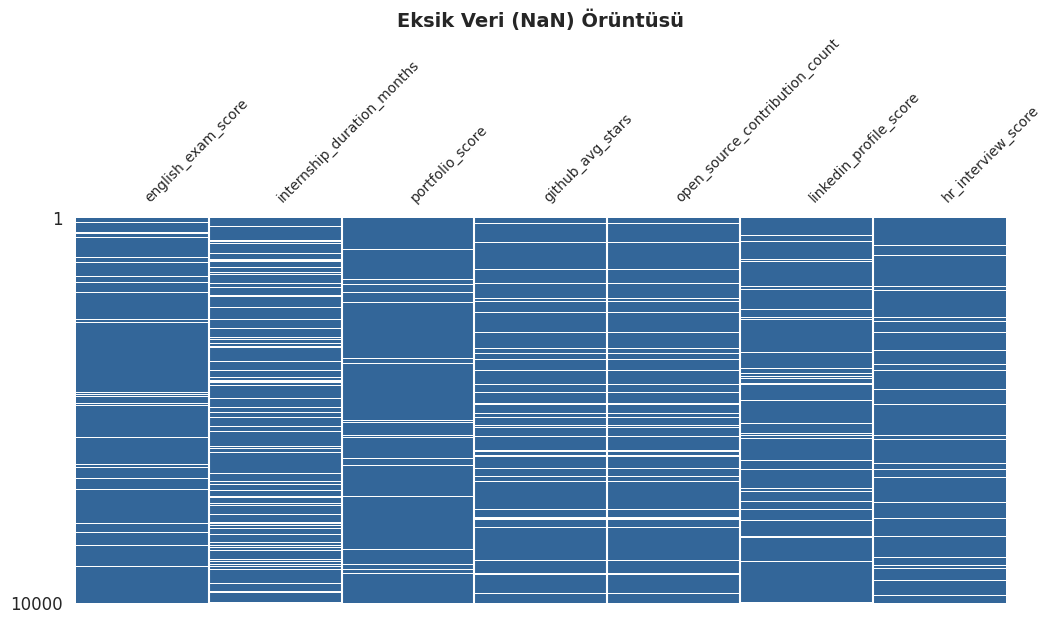

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Görselleştirme ayarları
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 5)

print("1. Hedef Değişken (Career Success Score) Analizi")
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Dağılım (Histogram & KDE)
sns.histplot(train_df['career_success_score'], bins=50, kde=True, ax=ax[0], color='#2E86C1')
ax[0].set_title('Hedef Değişken Dağılımı', fontweight='bold')
ax[0].set_xlabel('Career Success Score')

# Uç Değer Kontrolü (Boxplot ile)
sns.boxplot(x=train_df['career_success_score'], ax=ax[1], color='#48C9B0')
ax[1].set_title('Uç Değer (Outlier) Kontrolü', fontweight='bold')
ax[1].set_xlabel('Career Success Score')
plt.tight_layout()
plt.show()

# Skewness Analizi
skewness = train_df['career_success_score'].skew()
print(f"Hedef Değişken Çarpıklık (Skewness) Değeri: {skewness:.3f}")
if abs(skewness) > 1:
    print("Not: Dağılım çarpık. Logaritmik veya Box-Cox dönüşümü MSE skorunu iyileştirebilir.")
else:
    print("Not: Dağılım nispeten normal, regresyon modelleri doğrudan uygulanabilir.")

print("\n" + "="*60 + "\n")

print("2. Eksik Veri (Missing Value) Matrisi")
# Eksik veri içeren kolonları tespit etme
missing_cols = train_df.columns[train_df.isnull().sum() > 0]
missing_df = train_df[missing_cols].isnull().sum().sort_values(ascending=False).to_frame(name='Eksik_Sayısı')
missing_df['Eksik_Oranı(%)'] = (missing_df['Eksik_Sayısı'] / len(train_df)) * 100

print(missing_df.round(2))

# Eksik veriler arasında bir ilişki var mı? 
if len(missing_cols) > 0:
    plt.figure(figsize=(10, 4))
    msno.matrix(train_df[missing_cols], figsize=(12, 5), fontsize=10, sparkline=False, color=(0.2, 0.4, 0.6))
    plt.title("Eksik Veri (NaN) Örüntüsü", fontweight='bold', fontsize=14)
    plt.show()

Bu çok uzun sürer. Bunun yerine hangi sütunlarda eksik veri var, hangi sütunlar aşırı sıfır baskın, dağılımlar nasıl; bunları hızlıca görmek için ydata-profiling kullanıyoruz. Çıkan uyarıları okuyup önemli bulguları bir sonraki adımlara taşıyacağız. Html'den her analiz görüntülenebilir:

In [42]:
from ydata_profiling import ProfileReport

profile = ProfileReport(train_df, minimal=True, title="Student Career Success Score Prediction - Before EDA")
profile.to_file("data_report_before_eda2.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 47/47 [00:00<00:00, 47.67it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [43]:
from ydata_profiling import ProfileReport
import pandas as pd
import numpy as np

# 1. Yetenek sütunlarını tanımla
skill_cols = [
    'coding_score', 'problem_solving_score', 'data_structures_score',
    'sql_score', 'machine_learning_score', 'backend_score',
    'frontend_score', 'cloud_score', 'devops_score'
]

# 2. Yetenek Profil Analizi (temp_df üzerinden)
temp_df = train_df[skill_cols].copy()

# Yeni metrikleri temp_df'e ekliyoruz (train_df'e ASLA dokunmuyoruz)
temp_df['std_dev'] = temp_df.std(axis=1)
temp_df['max_skill'] = temp_df.max(axis=1)
temp_df['min_skill'] = temp_df.min(axis=1)
temp_df['expert_count'] = (temp_df[skill_cols] > 80).sum(axis=1)
temp_df['failed_count'] = (temp_df[skill_cols] < 50).sum(axis=1)

# 3. ydata-profiling: Sadece bu profil DataFrame'ini analiz et
print("\n▶ Sadece yetenek profilin röntgeni çekiliyor (train_df'e dokunulmadı)...")
profile = ProfileReport(temp_df, title="Öğrenci Yetenek Profili Analizi", explorative=True)
profile.to_file("student_profile_analysis.html")

print("\n✔ Analiz tamam! 'student_profile_analysis.html' dosyasını sol panelden indirebilirsin.")


▶ Sadece yetenek profilin röntgeni çekiliyor (train_df'e dokunulmadı)...


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 14/14 [00:00<00:00, 70.93it/s][A


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]


✔ Analiz tamam! 'student_profile_analysis.html' dosyasını sol panelden indirebilirsin.


## 2.1. İlişki ve Korelasyon Analizi
Modelin ezber (overfit) eğilimini anlamak için temel değişkenler arası ilişkiler.

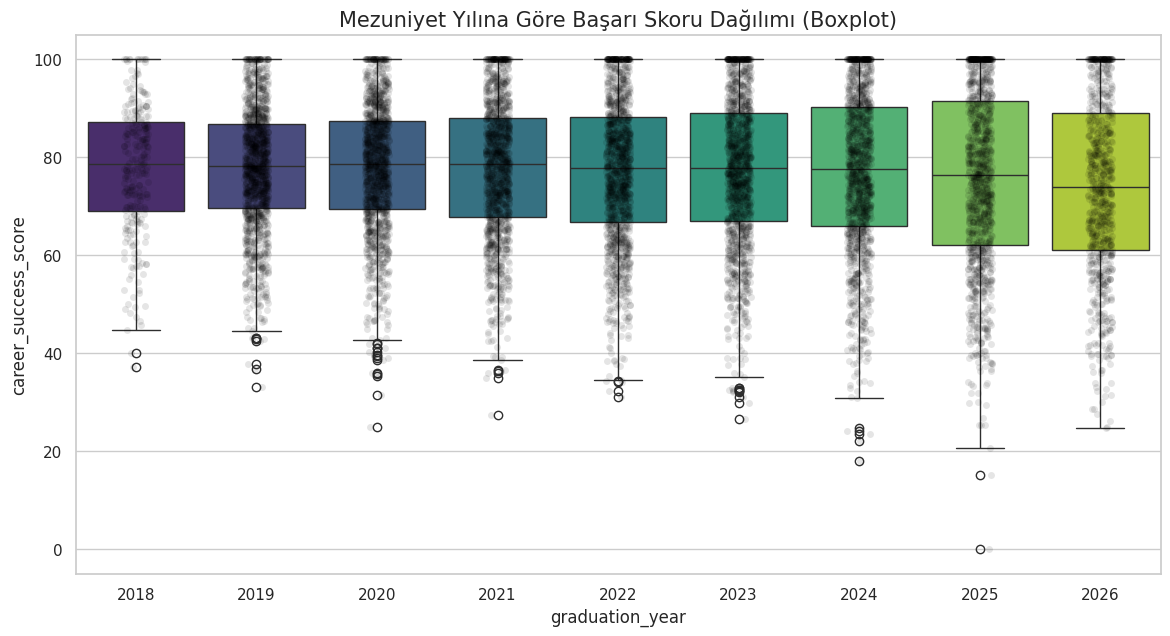

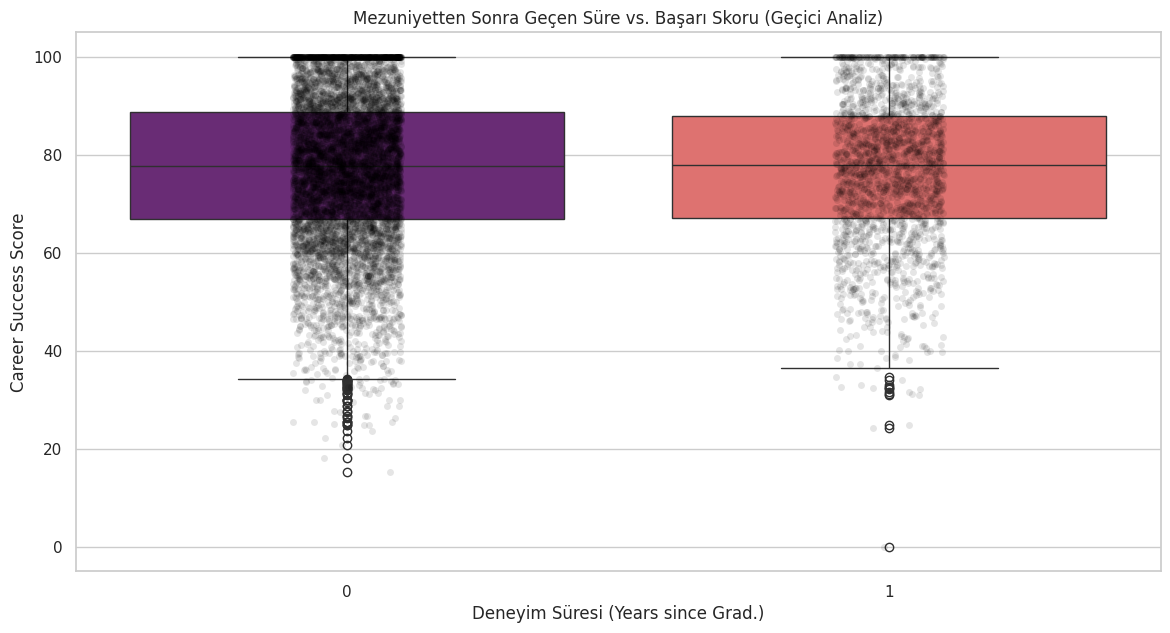

Deneyim Süresi ile Başarı Skoru Korelasyonu: -0.0052


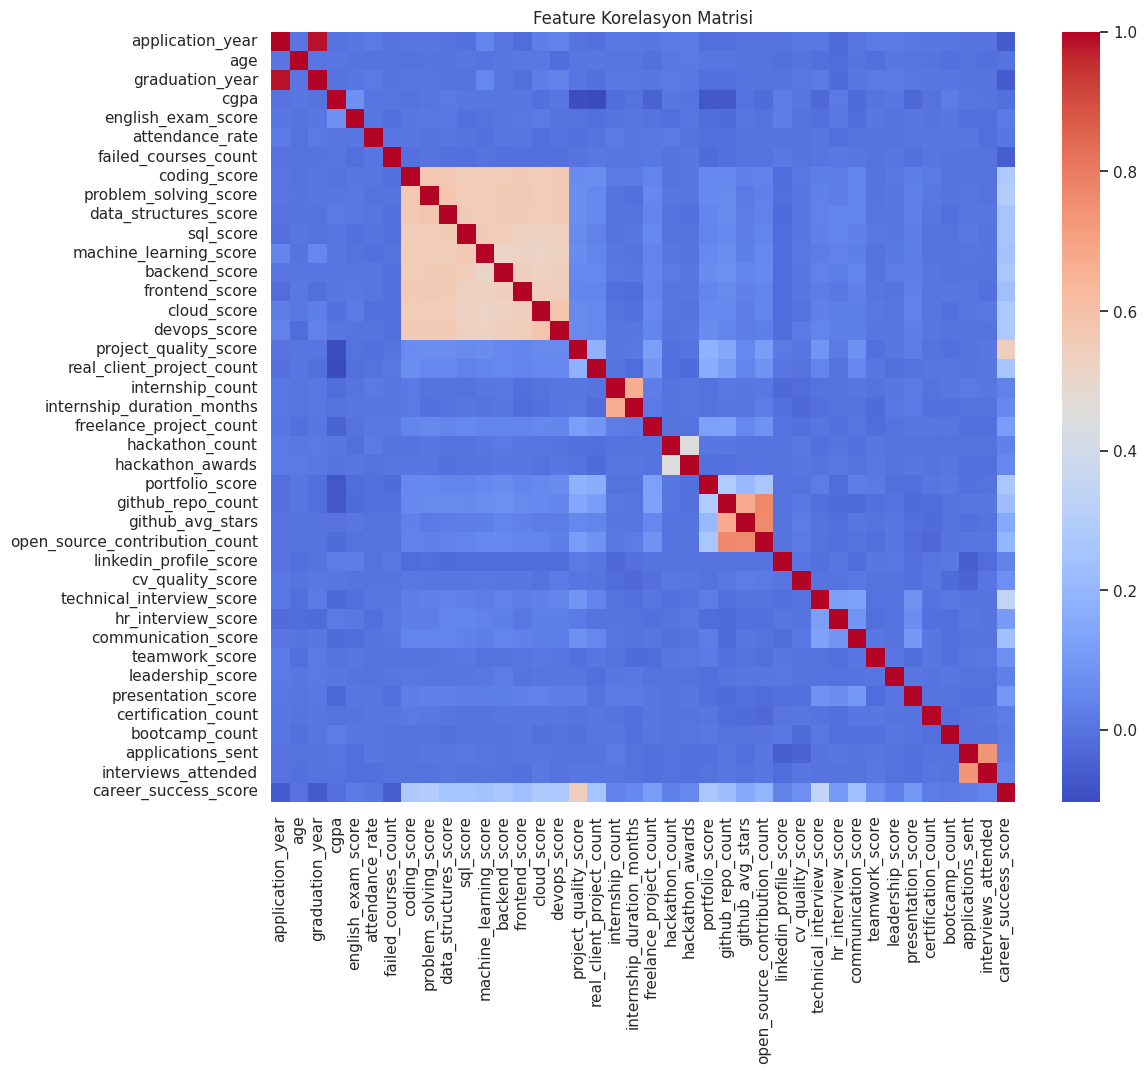

--- Birbirini En Çok Tekrar Eden Özellikler ---
graduation_year   application_year    0.98434
application_year  graduation_year     0.98434
dtype: float64


In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Years vs Success 
plt.figure(figsize=(14, 7))

# X ekseninde yıllar, Y ekseninde skorlar
sns.boxplot(data=train_df, x='graduation_year', y='career_success_score', palette='viridis')

# Veri noktalarını (noktaların üzerine) ekleyelim ki yığılmayı görelim
sns.stripplot(data=train_df, x='graduation_year', y='career_success_score', color='black', alpha=0.1)

plt.title("Mezuniyet Yılına Göre Başarı Skoru Dağılımı (Boxplot)", fontsize=15)
plt.show()

# Orijinal df'e dokunmuyoruz, sadece plot için geçici bir view alıyoruz
temp_plot_df = train_df.copy()
temp_plot_df['years_since_graduation'] = temp_plot_df['application_year'] - temp_plot_df['graduation_year']

plt.figure(figsize=(14, 7))

# Sadece bu geçici df üzerinden grafik çiziyoruz
sns.boxplot(data=temp_plot_df, x='years_since_graduation', y='career_success_score', palette='magma')
sns.stripplot(data=temp_plot_df, x='years_since_graduation', y='career_success_score', color='black', alpha=0.1)

plt.title("Mezuniyetten Sonra Geçen Süre vs. Başarı Skoru (Geçici Analiz)")
plt.xlabel("Deneyim Süresi (Years since Grad.)")
plt.ylabel("Career Success Score")
plt.show()

# Korelasyonu da yine bu geçici df'ten alıyoruz
corr_val = temp_plot_df['years_since_graduation'].corr(temp_plot_df['career_success_score'])
print(f"Deneyim Süresi ile Başarı Skoru Korelasyonu: {corr_val:.4f}")

# temp_plot_df zaten bir alt satıra geçince çöp oluyor, train_df'in tertemiz kalıyor.
# 2. Genel Özellik Korelasyon Matrisi (Hangi özellikler ikiz?)
numeric_df = train_df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title("Feature Korelasyon Matrisi")
plt.show()

# 3. İkiz Özellikleri Yakalama (Feature Pruning hazırlığı)
high_corr = corr_matrix.unstack().sort_values(ascending=False)
high_corr = high_corr[(high_corr > 0.90) & (high_corr < 1.0)]
print("--- Birbirini En Çok Tekrar Eden Özellikler ---")
print(high_corr.head(10))

# application_year, gradation_year ve career_success score arasındakii ilişki olmalı

## 3. Veri Ön İşleme ve Hazırlık

Hızlı bir şeyler yapalım, sonra düzeltiriz:

In [45]:
# 1. 'eksik' olanları doğrudan NaN yap
train_df['university_tier'] = train_df['university_tier'].replace('eksik', np.nan)
test_df['university_tier'] = test_df['university_tier'].replace('eksik', np.nan)

# 2. Mapping işlemini NaN'lere dokunmadan yap (NaN'ler olduğu gibi kalır)
tier_mapping = {
    'tier 4': 1,
    'tier 3': 2,
    'tier 2': 3,
    'tier 1': 4
}
train_df['university_tier'] = train_df['university_tier'].map(tier_mapping)
test_df['university_tier'] = test_df['university_tier'].map(tier_mapping)

# 3. İPUCU: Artık elimizde NaN (eksik) değerler var. 
# CatBoost bunu kendi başına "özel bir grup" olarak işleyecektir!

In [46]:
# Eğer staj sayısı 0 ise veya boşsa, staj süresi 0'dır
train_df['internship_duration_months'] = train_df.apply(
    lambda row: 0 if row['internship_count'] == 0 else row['internship_duration_months'], axis=1
)
test_df['internship_duration_months'] = test_df.apply(
    lambda row: 0 if row['internship_count'] == 0 else row['internship_duration_months'], axis=1
)

In [47]:
# Github reposu 0 olanların yıldızı ve katkısı da 0'dır
github_cols = ['github_avg_stars', 'open_source_contribution_count']
for col in github_cols:
    train_df[col] = train_df.apply(lambda row: 0 if row['github_repo_count'] == 0 else row[col], axis=1)
    test_df[col] = test_df.apply(lambda row: 0 if row['github_repo_count'] == 0 else row[col], axis=1)

In [48]:
# -999 sentinel değerlerini tespit et
sentinel_cols = [col for col in train_df.select_dtypes('number').columns
                 if (train_df[col] == -999).any()]
print("Gizli missing (-999) sütunlar:", sentinel_cols)

# NaN'a çevir
train_df[sentinel_cols] = train_df[sentinel_cols].replace(-999, np.nan)
test_df[sentinel_cols]  = test_df[sentinel_cols].replace(-999, np.nan)

Gizli missing (-999) sütunlar: []


In [49]:
# Kategorik Eksiklikler (Kategorik veri tipine 'Eksik' sınıfını ekleyip dolduruyoruz)
cat_features = train_df.select_dtypes(include=['category']).columns.tolist()
for col in cat_features:
    if "Eksik" not in train_df[col].cat.categories:
        train_df[col] = train_df[col].cat.add_categories("Eksik")
    if "Eksik" not in test_df[col].cat.categories:
        test_df[col] = test_df[col].cat.add_categories("Eksik")
    train_df[col] = train_df[col].fillna("Eksik")
    test_df[col] = test_df[col].fillna("Eksik")

CatBoost bu 32 kolona baktığında aslında metni okumaz, o koordinatlara bakar ve kendi içinde şu mantığı kurar:
"PCA_1 değeri yüksek ve PCA_14 değeri düşük olan öğrenciler, genellikle mentörlerin 'Teknik yeteneği çok iyi ama takım çalışması zayıf' dediği öğrenciler. Ben geçmiş veriden öğrendim ki bu tip öğrencilerin Kariyer Başarı Skoru (MSE) genelde 75-80 bandında oluyor."

In [50]:
print("Train:")
train_df.head()

Train:


,student_id,application_year,age,graduation_year,department,university_tier,cgpa,english_exam_score,attendance_rate,failed_courses_count,...,leadership_score,presentation_score,certification_count,bootcamp_count,applications_sent,interviews_attended,hobby,preferred_social_media_platform,career_success_score,mentor_feedback_text
0,STU_000001,2021,21,2021,computer engineering,1,3.17,62.540001,77.309998,0,...,62.700001,58.840000,3,1,24,0,photography,linkedin,86.779999,Proje kalitesi ve makine öğrenimi konusundaki ...
1,STU_000002,2024,20,2024,computer engineering,1,3.24,75.099998,87.129997,3,...,42.320000,40.540001,2,0,46,5,reading,youtube,46.160000,Kodlama ve problem çözme becerileri gelişmekte...
2,STU_000003,2024,28,2024,electrical electronics engineering,1,3.00,68.529999,95.639999,1,...,47.270000,82.559998,1,2,46,5,cinema,reddit,84.080002,İleri düzey frontend geliştirme becerileri ile...
3,STU_000004,2019,22,2018,computer engineering,4,2.82,54.849998,77.800003,2,...,78.690002,85.050003,2,4,49,7,running,reddit,89.970001,Güçlü bir kodlama yeteneği ve backend geliştir...
4,STU_000005,2026,22,2026,computer engineering,2,2.28,72.250000,71.970001,1,...,27.219999,84.290001,1,0,119,13,football,x,92.459999,Ürün analizi alanına olan tutkusu ve makine öğ...


In [51]:
print("Train:")
test_df.head()

Train:


,student_id,application_year,age,graduation_year,department,university_tier,cgpa,english_exam_score,attendance_rate,failed_courses_count,...,teamwork_score,leadership_score,presentation_score,certification_count,bootcamp_count,applications_sent,interviews_attended,hobby,preferred_social_media_platform,mentor_feedback_text
0,STU_010001,2025,23,2025,computer engineering,1,2.59,45.270000,79.110001,2,...,90.019997,81.330002,30.540001,6,2,46,6,gaming,youtube,Öğrencinin proje çalışmasında dikkat çekici bi...
1,STU_010002,2023,23,2022,electrical electronics engineering,2,3.12,66.300003,70.580002,1,...,82.779999,82.779999,42.369999,1,0,4,0,football,tiktok,"Bu öğrenci, problem çözme ve veri yapıları kon..."
2,STU_010003,2025,20,2025,computer engineering,2,3.48,75.449997,67.930000,0,...,51.790001,63.299999,66.010002,4,1,66,3,cinema,instagram,Öğrencinin veri bilimi konusundaki ilgisi ve g...
3,STU_010004,2020,26,2019,software engineering,3,2.92,45.580002,83.949997,0,...,90.889999,46.639999,82.599998,3,2,42,2,chess,linkedin,Son derece etkileyici bir başarıya imza atan b...
4,STU_010005,2024,21,2024,computer engineering,2,2.85,63.080002,84.180000,1,...,42.779999,43.299999,39.650002,3,1,25,0,reading,tiktok,Öğrencinin yazılım geliştirme alanındaki çalış...


### 3.1. Temel Veri Analizi
Oturumdaki aksiyonlar, zamansallık .. etiketi üzerine temel görselleştirmelerin yapılması.

In [52]:
from ydata_profiling import ProfileReport

profile = ProfileReport(train_df, minimal=True, title="Student Career Success Score Prediction — After EDA")
profile.to_file("data_report_after_eda_18.54.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 47/47 [00:00<00:00, 48.97it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

- TabPFN ve Catboost Shap Sonucunda:

In [53]:
# Interaction features (SHAP'tan çıkan top 3 arasında)
""""
for df in [train_df, test_df]:
    df['proj_x_tech'] = df['project_quality_score'] * df['technical_interview_score']
    df['proj_x_comm'] = df['project_quality_score'] * df['communication_score']
    df['tech_x_comm'] = df['technical_interview_score'] * df['communication_score']
    df['top3_mean']   = (df['project_quality_score'] + df['technical_interview_score'] + df['communication_score']) / 3
 """   
print("a")
    

a


## 4. Özellik Mühendisliği Fonksiyonları

### 4.1. Mentor Geri Bildirimleri NLP Özellik Çıkarımı (TF-IDF / BERT Embeddings)

In [54]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
import pandas as pd

# 1. ÖZEL STOP-WORDS LİSTESİ (Duygu derecelerini koruyoruz: daha, çok, en HARİÇ)
custom_stop_words = [
    'acaba', 'ama', 'aslında', 'az', 'bazı', 'belki', 'biri', 'birkaç', 'birşey', 'biz', 
    'bu', 'da', 'de', 'defa', 'diye', 'gibi', 'hem', 'hep', 'hiç', 'için', 'ile', 'ise', 
    'kez', 'ki', 'kim', 'mı', 'mu', 'mü', 'nasıl', 'ne', 'neden', 'nerde', 'nerede', 
    'niye', 'olan', 'olarak', 'oldu', 'olduğu', 'olmak', 'oysa', 'sanki', 'şey', 'siz', 
    'şu', 'tüm', 've', 'veya', 'ya', 'yani'
]
# 'bir' kelimesini de ekleyebilirsin ama 'birinci' anlamı taşıyorsa riskli olabilir.

print("▶ 1. Aşama: TF-IDF Vektörleri Üretiliyor (CatBoost İçin)...")
tfidf = TfidfVectorizer(
    max_features=500, 
    ngram_range=(1, 2),
    stop_words=custom_stop_words # Özel listemizi verdik
)

train_tfidf = tfidf.fit_transform(train_df['mentor_feedback_text'])
test_tfidf = tfidf.transform(test_df['mentor_feedback_text'])

# Sütun isimlerini temizle (Boşlukları alt tire yap)
tfidf_cols = [f"tfidf_{word.replace(' ', '_')}" for word in tfidf.get_feature_names_out()]

print("▶ 2. Aşama: SVD ile Boyut İndirgeniyor (TabPFN İçin)...")
# TabPFN çok yüksek boyutta zorlanabilir, 64 harika bir sıkıştırma oranı
svd = TruncatedSVD(n_components=64, random_state=42) 
train_svd = svd.fit_transform(train_tfidf)
test_svd = svd.transform(test_tfidf)
svd_cols = [f"svd_{i}" for i in range(64)]

print("▶ 3. Aşama: DataFrame'e Entegrasyon...")
# Bellek tasarrufu için concat yaparken pd.DataFrame index'lerini güvene alıyoruz
train_df = pd.concat([
    train_df.reset_index(drop=True), 
    pd.DataFrame(train_tfidf.toarray(), columns=tfidf_cols),
    pd.DataFrame(train_svd, columns=svd_cols)
], axis=1)

test_df = pd.concat([
    test_df.reset_index(drop=True), 
    pd.DataFrame(test_tfidf.toarray(), columns=tfidf_cols),
    pd.DataFrame(test_svd, columns=svd_cols)
], axis=1)

print("İşlem Başarılı! CatBoost 500 özellikten, TabPFN ise yoğunlaştırılmış 64 özellikten faydalanacak.")

▶ 1. Aşama: TF-IDF Vektörleri Üretiliyor (CatBoost İçin)...
▶ 2. Aşama: SVD ile Boyut İndirgeniyor (TabPFN İçin)...
▶ 3. Aşama: DataFrame'e Entegrasyon...
İşlem Başarılı! CatBoost 500 özellikten, TabPFN ise yoğunlaştırılmış 64 özellikten faydalanacak.


In [55]:
print(f"Toplam {len(tfidf_cols)} TF-IDF kelimesi üretildi.\n")
print("İlk 500 kelime:")
print(tfidf.get_feature_names_out())

Toplam 500 TF-IDF kelimesi üretildi.

İlk 500 kelime:
['aday' 'aday haline' 'aday yapıyor' 'adım' 'adımlar' 'ai'
 'ai mühendisliği' 'aktif' 'alan' 'alanda' 'alandaki' 'alanlar'
 'alanlarda' 'alanlarında' 'alanına' 'alanında' 'alanında daha'
 'alanında güçlü' 'alanında sağlam' 'alanındaki' 'analisti' 'analitik'
 'analizi' 'analizi alanında' 'ancak' 'ancak daha' 'ancak iletişim'
 'ancak kodlama' 'ancak problem' 'ancak proje' 'ancak takım'
 'ancak teknik' 'arka' 'arka uç' 'artırabilir' 'artırarak' 'artırmak'
 'artırmak daha' 'artırması' 'avantaj' 'avantaj sağlayacaktır'
 'avantaj sağlıyor' 'ayrıca' 'açık' 'açık kaynak' 'açısından' 'backend'
 'backend geliştirme' 'başarı' 'başarıları' 'başarılı' 'başarılı bir'
 'başarısı' 'becerileri' 'becerileri dikkat' 'becerileri oldukça'
 'becerileri üzerinde' 'becerilerin' 'becerilerinde' 'becerilerinde daha'
 'becerilerini' 'becerilerini daha' 'becerilerini geliştirmek'
 'becerilerini geliştirmesi' 'becerilerinin' 'becerileriniz'
 'becerilerinizi' 'b

In [56]:
print("Train:")
train_df.head()

Train:


,student_id,application_year,age,graduation_year,department,university_tier,cgpa,english_exam_score,attendance_rate,failed_courses_count,...,svd_54,svd_55,svd_56,svd_57,svd_58,svd_59,svd_60,svd_61,svd_62,svd_63
0,STU_000001,2021,21,2021,computer engineering,1,3.17,62.540001,77.309998,0,...,-0.020703,-0.061775,0.051791,0.015520,-0.005432,0.032702,-0.005388,-0.030480,0.014023,-0.013750
1,STU_000002,2024,20,2024,computer engineering,1,3.24,75.099998,87.129997,3,...,-0.046741,0.032364,0.007017,-0.040089,0.045453,0.013151,0.062420,0.018442,-0.065302,0.218909
2,STU_000003,2024,28,2024,electrical electronics engineering,1,3.00,68.529999,95.639999,1,...,0.035837,0.010299,0.114161,0.054819,0.065696,-0.037642,0.123817,-0.011594,0.024534,0.023582
3,STU_000004,2019,22,2018,computer engineering,4,2.82,54.849998,77.800003,2,...,0.086156,-0.089748,-0.043394,0.037501,-0.059618,0.019940,-0.025260,0.009737,0.125061,0.025890
4,STU_000005,2026,22,2026,computer engineering,2,2.28,72.250000,71.970001,1,...,-0.072773,-0.002234,0.061721,0.069102,0.120183,-0.017459,0.000660,0.051747,-0.011469,-0.043902


## 5. Veri Seti Hazırlama

- **`final_train_df`:** Eğitim verisi (session_value hedef değişkeni ile)
- **`final_test_df`:** Test verisi (tahmin yapılacak oturumlar)

## 6. Model Eğitimi ve CV

PREPROCESSING

In [57]:
target = 'career_success_score'
features = [col for col in train_df.columns if col not in ['student_id', target]]

from sklearn.preprocessing import LabelEncoder

train_df_enc = train_df.copy()
test_df_enc  = test_df.copy()

cat_cols_tabpfn = [
    c for c in features
    if train_df_enc[c].dtype in ['object', 'category']
    or test_df_enc[c].dtype in ['object', 'category']
]

for col in cat_cols_tabpfn:
    le = LabelEncoder()
    train_df_enc[col] = pd.Series(
        le.fit_transform(train_df_enc[col].astype(str)).astype('int64'),
        index=train_df_enc.index
    )
    known = set(le.classes_)
    test_df_enc[col] = pd.Series(
        test_df_enc[col].astype(str).map(
            lambda x: le.transform([x])[0] if x in known else -1
        ).astype('int64'),
        index=test_df_enc.index
    )

X      = train_df[features]
X_test = test_df[features]

X_enc      = train_df_enc[features].copy().astype('float64')
X_test_enc = test_df_enc[features].copy().astype('float64')

num_cols = X_enc.select_dtypes(include=[np.number]).columns
train_medians = X_enc[num_cols].median()
X_enc[num_cols]      = X_enc[num_cols].fillna(train_medians)
X_test_enc[num_cols] = X_test_enc[num_cols].fillna(train_medians)

y = train_df[target]
print(f"Toplam feature: {len(features)}")

Toplam feature: 609


CATBOOST TRAINING

In [69]:
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. CatBoost İçin Özellikleri (Features) Sıfırdan Belirliyoruz
# SVD kolonlarını, ID, hedef değişken ve ham metin kolonunu kesin olarak atıyoruz
drop_cols = svd_cols + ['student_id', 'career_success_score', 'mentor_feedback_text']
cb_features = [c for c in train_df.columns if c not in drop_cols]

# 2. CatBoost'a Özel X ve y Veri Setleri
X_cb = train_df[cb_features].copy()
y_cb = train_df['career_success_score'].copy()
X_test_cb = test_df[cb_features].copy()

# 3. Kategorik Değişkenleri Güvenli Şekilde Tanımla (Sadece X_cb içinde kalanlar)
cb_cat_features = X_cb.select_dtypes(include=['object', 'category']).columns.tolist()

# 4. K-Fold ile Model Eğitimi
kf = KFold(n_splits=5, shuffle=True, random_state=42)
test_preds_catboost = np.zeros(len(X_test_cb))
cv_scores_cb = []
cb_oof_preds = np.zeros(len(X_cb))  # <--- BİRİNCİ EKSİK SATIR EKLENDİ

print("\n--- CatBoost Eğitimi Başlıyor ---")
for fold, (train_idx, val_idx) in enumerate(kf.split(X_cb, y_cb)):
    # Fold'ları ayır
    X_tr, y_tr = X_cb.iloc[train_idx], y_cb.iloc[train_idx]
    X_va, y_va = X_cb.iloc[val_idx], y_cb.iloc[val_idx]

    # Modeli tanımla
    cb_model = CatBoostRegressor(
        iterations=1500, 
        learning_rate=0.05, 
        depth=6,
        cat_features=cb_cat_features, 
        eval_metric='RMSE',
        random_seed=42, 
        verbose=250 # Süreci görmek için 0 yerine 250 yaptım
    )
    
    # Modeli eğit
    cb_model.fit(X_tr, y_tr, eval_set=(X_va, y_va), early_stopping_rounds=100)

    # Tahminler ve Skor
    cb_val_preds = cb_model.predict(X_va)
    cb_oof_preds[val_idx] = cb_val_preds  # <--- İKİNCİ EKSİK SATIR EKLENDİ
    fold_mse = mean_squared_error(y_va, cb_val_preds)
    cv_scores_cb.append(fold_mse)
    
    # Test setine tahmin ekle
    test_preds_catboost += cb_model.predict(X_test_cb) / kf.n_splits
    
    print(f"Fold {fold+1} | CatBoost MSE: {fold_mse:.4f}")

print(f"\n---> CatBoost Ort. CV MSE: {np.mean(cv_scores_cb):.4f}")


--- CatBoost Eğitimi Başlıyor ---
0:	learn: 14.9123246	test: 14.8952653	best: 14.8952653 (0)	total: 87.2ms	remaining: 2m 10s
250:	learn: 8.2699710	test: 9.2853096	best: 9.2852077 (249)	total: 15.6s	remaining: 1m 17s
500:	learn: 7.2668424	test: 9.1340544	best: 9.1340544 (500)	total: 31s	remaining: 1m 1s
750:	learn: 6.5347961	test: 9.1045562	best: 9.1045562 (750)	total: 46.1s	remaining: 46s
1000:	learn: 5.9817262	test: 9.0885832	best: 9.0881424 (957)	total: 1m	remaining: 30.2s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 9.088142384
bestIteration = 957

Shrink model to first 958 iterations.
Fold 1 | CatBoost MSE: 82.5943
0:	learn: 14.8355945	test: 15.0994060	best: 15.0994060 (0)	total: 60.2ms	remaining: 1m 30s
250:	learn: 8.1543838	test: 9.4155361	best: 9.4154019 (249)	total: 15s	remaining: 1m 14s
500:	learn: 7.2031015	test: 9.2441167	best: 9.2441167 (500)	total: 30.1s	remaining: 1m
750:	learn: 6.5565584	test: 9.1869423	best: 9.1867797 (734)	total: 45.1s	remaining:

In [70]:
print([c for c in X_va_cb.columns if c.startswith('tfidf_')][:5])


['tfidf_aday', 'tfidf_aday_haline', 'tfidf_aday_yapıyor', 'tfidf_adım', 'tfidf_adımlar']


Toplam feature: 544
tfidf_ ile başlayan: 500


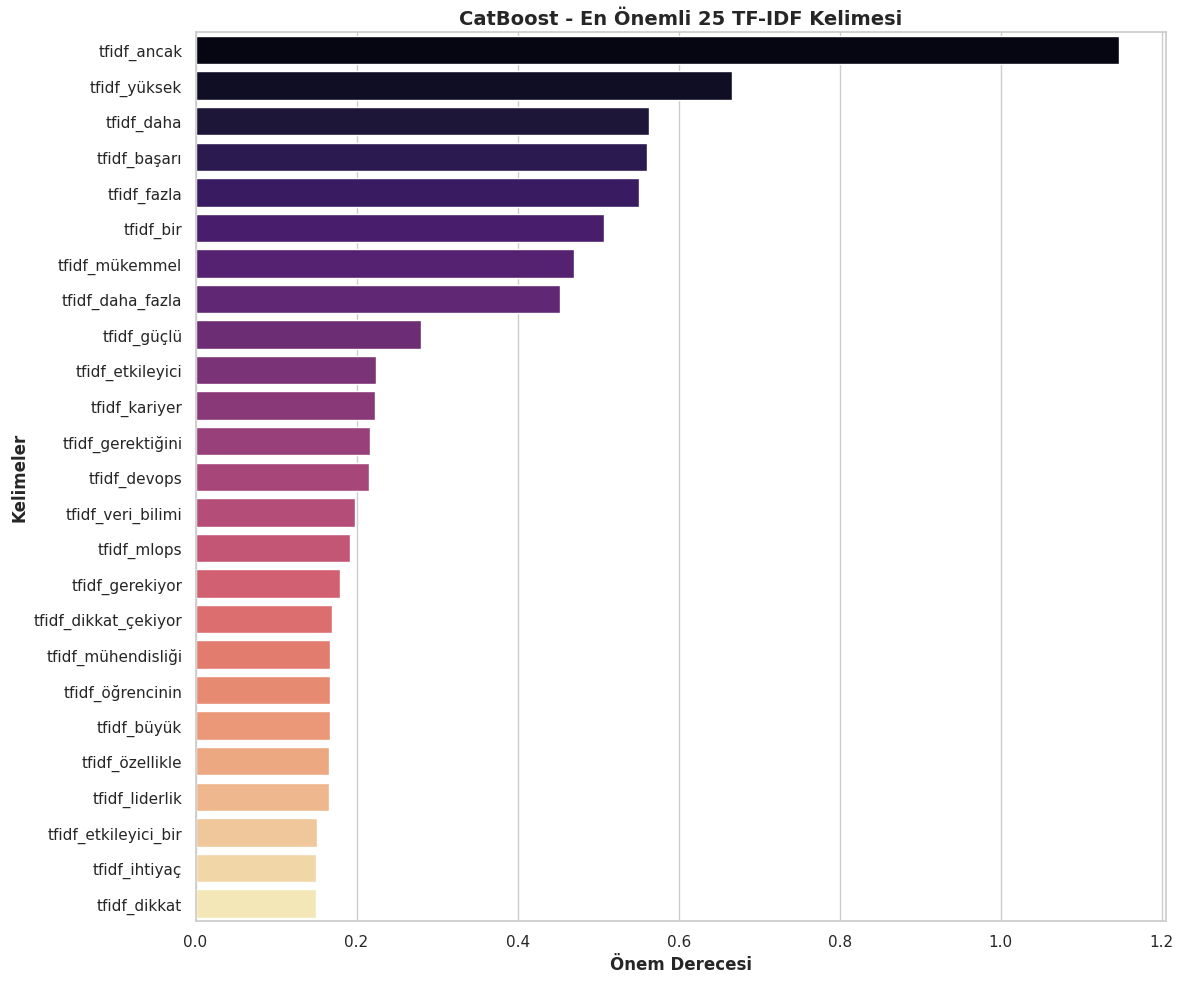


▶ En Önemli 10 TF-IDF Kelimesi:
         Feature  Importance
     tfidf_ancak    1.147392
    tfidf_yüksek    0.665823
      tfidf_daha    0.563253
    tfidf_başarı    0.560980
     tfidf_fazla    0.550655
       tfidf_bir    0.507557
  tfidf_mükemmel    0.470245
tfidf_daha_fazla    0.453255
     tfidf_güçlü    0.279866
tfidf_etkileyici    0.224398


In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Önemli Düzeltme: X_va_cb.columns yerine cb_model.feature_names_ kullanıyoruz!
feature_importances = cb_model.get_feature_importance()

importance_df = pd.DataFrame({
    'Feature': cb_model.feature_names_,  # <--- Hata verdirmeyen doğru kullanım
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# 2. Genel istatistikleri yazdır
print(f"Toplam feature: {len(importance_df)}")
print(f"tfidf_ ile başlayan: {len(importance_df[importance_df['Feature'].str.startswith('tfidf_')])}")

# 3. Sadece TF-IDF özelliklerini (kelimeleri) filtrele
tfidf_importance = importance_df[importance_df['Feature'].str.startswith('tfidf_')]

# 4. Görselleştirme (Grafik Çizimi)
plt.figure(figsize=(12, 10))

# Seaborn uyarılarını engellemek için hue='Feature' ve legend=False eklendi
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=tfidf_importance.head(25), 
    palette='magma',
    hue='Feature',
    legend=False
)

plt.title('CatBoost - En Önemli 25 TF-IDF Kelimesi', fontweight='bold', fontsize=14)
plt.xlabel('Önem Derecesi', fontweight='bold')
plt.ylabel('Kelimeler', fontweight='bold')
plt.tight_layout()
plt.show()

# 5. En önemli 10 kelimeyi liste olarak bastır
print("\n▶ En Önemli 10 TF-IDF Kelimesi:")
print(tfidf_importance.head(10).to_string(index=False))

TABPFN TRAINING

In [63]:
!pip install tabpfn tabpfn-extensions

In [64]:
from tabpfn.settings import settings
print(settings.tabpfn.model_version)

ModelVersion.V3


In [65]:
import os
os.environ["TABPFN_TOKEN"] = "tabpfn_sk_KUBFttGyxGUSuRM5PX__yZhsATp3G_uAFVWwyCeDpG8"
from tabpfn import TabPFNRegressor

test_preds_tabpfn = np.zeros(len(X_test_enc))
cv_scores_tab = []
tp_oof_preds = np.zeros(len(X_enc))

for fold, (train_idx, val_idx) in enumerate(kf.split(X_enc, y)):
    X_tr_tab = X_enc.iloc[train_idx].drop(columns=tfidf_cols)
    X_va_tab = X_enc.iloc[val_idx].drop(columns=tfidf_cols)
    y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]

    tp_model = TabPFNRegressor(fit_mode="fit_with_cache", device='cuda')
    tp_model.fit(X_tr_tab, y_tr)

    tp_val_preds = tp_model.predict(X_va_tab)
    cv_scores_tab.append(mean_squared_error(y_va, tp_val_preds))
    test_preds_tabpfn += tp_model.predict(X_test_enc.drop(columns=tfidf_cols)) / kf.n_splits
    tp_oof_preds[val_idx] = tp_val_preds
    print(f"Fold {fold+1} | TabPFN MSE: {cv_scores_tab[-1]:.4f}")

print(f"\n---> TabPFN Ort. CV MSE: {np.mean(cv_scores_tab):.4f}")
print(f"---> CatBoost Ort. CV MSE: {np.mean(cv_scores_cb):.4f}")

Fold 1 | TabPFN MSE: 82.6863
Fold 2 | TabPFN MSE: 82.0437
Fold 3 | TabPFN MSE: 73.1445
Fold 4 | TabPFN MSE: 77.2031
Fold 5 | TabPFN MSE: 81.9477

---> TabPFN Ort. CV MSE: 79.4050
---> CatBoost Ort. CV MSE: 80.4416


In [66]:
for w_tp in [0.5, 0.55, 0.6, 0.65, 0.7]:
    blend = (cb_oof_preds * (1-w_tp)) + (tp_oof_preds * w_tp)
    mse = mean_squared_error(y_cb, blend)
    print(f"TabPFN ağırlık: {w_tp:.2f} | OOF MSE: {mse:.4f}")

Toplam 64 SVD boyutu üretildi.
SVD sütun isimleri: ['svd_0', 'svd_1', 'svd_2', 'svd_3', 'svd_4', 'svd_5', 'svd_6', 'svd_7', 'svd_8', 'svd_9', 'svd_10', 'svd_11', 'svd_12', 'svd_13', 'svd_14', 'svd_15', 'svd_16', 'svd_17', 'svd_18', 'svd_19', 'svd_20', 'svd_21', 'svd_22', 'svd_23', 'svd_24', 'svd_25', 'svd_26', 'svd_27', 'svd_28', 'svd_29', 'svd_30', 'svd_31', 'svd_32', 'svd_33', 'svd_34', 'svd_35', 'svd_36', 'svd_37', 'svd_38', 'svd_39', 'svd_40', 'svd_41', 'svd_42', 'svd_43', 'svd_44', 'svd_45', 'svd_46', 'svd_47', 'svd_48', 'svd_49', 'svd_50', 'svd_51', 'svd_52', 'svd_53', 'svd_54', 'svd_55', 'svd_56', 'svd_57', 'svd_58', 'svd_59', 'svd_60', 'svd_61', 'svd_62', 'svd_63']

Her SVD bileşeninin temsil ettiği en önemli 5 kelime:
SVD_0: ['bir', 'daha', 'fazla', 'daha fazla', 'ancak']
SVD_1: ['makine', 'öğrenimi', 'makine öğrenimi', 'veri', 'bilimi']
SVD_2: ['bir', 'açık kaynak', 'kaynak', 'açık', 'onu']
SVD_3: ['problem', 'problem çözme', 'çözme', 'dikkat', 'proje kalitesi']
SVD_4: ['açık

BLEND HALİNİN MSE'Sİ:

In [72]:
for w_tp in [0.5, 0.55, 0.6, 0.65, 0.7]:
    blend = (cb_oof_preds * (1-w_tp)) + (tp_oof_preds * w_tp)
    mse = mean_squared_error(y, blend)
    print(f"TabPFN ağırlık: {w_tp:.2f} | OOF MSE: {mse:.4f}")

TabPFN ağırlık: 0.50 | OOF MSE: 77.6756
TabPFN ağırlık: 0.55 | OOF MSE: 77.6463
TabPFN ağırlık: 0.60 | OOF MSE: 77.6619
TabPFN ağırlık: 0.65 | OOF MSE: 77.7224
TabPFN ağırlık: 0.70 | OOF MSE: 77.8279


## 7. Catboost Prediction
- Yarışma submission için test seti tahminleri
- Tüm fold modellerinin ortalaması

In [73]:
import pandas as pd
import numpy as np

final_cb_preds = np.clip(test_preds_catboost, 0, 100)

submission = pd.DataFrame({
    'student_id': test_df['student_id'],
    target: final_cb_preds
})

submission.to_csv(f"{OUTPUT_DIR}/submission_v5_catboost.csv", index=False)
print("CatBoost submission oluşturuldu.")

CatBoost submission oluşturuldu.


## 8. Catboost Feature Importance ve SHAP

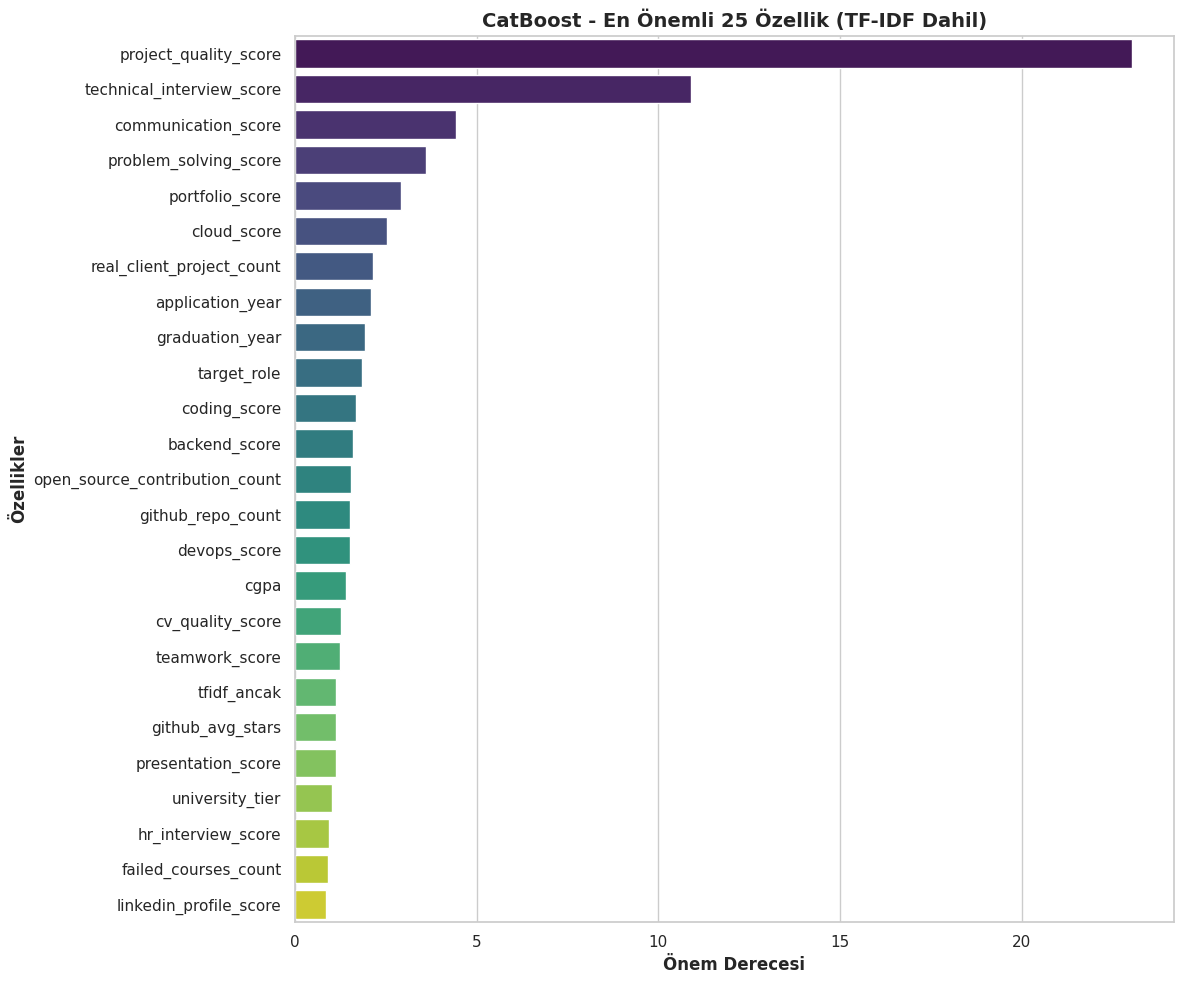


▶ İlk 5 Özellik:
                  Feature  Importance
    project_quality_score   23.034041
technical_interview_score   10.889055
      communication_score    4.438810
    problem_solving_score    3.618376
          portfolio_score    2.910029


In [75]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Önemleri al
feature_importances = cb_model.get_feature_importance()

# 2. KRİTİK DÜZELTME: X_va_cb.columns YERİNE cb_model.feature_names_
importance_df = pd.DataFrame({
    'Feature': cb_model.feature_names_,  # <--- Hata verdirmeyen doğru kullanım
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# 3. Görselleştirme
plt.figure(figsize=(12, 10))

# Seaborn uyarılarını (FutureWarning) engellemek için hue='Feature' ve legend=False eklendi
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=importance_df.head(25), 
    palette='viridis',
    hue='Feature',
    legend=False
)

plt.title('CatBoost - En Önemli 25 Özellik (TF-IDF Dahil)', fontweight='bold', fontsize=14)
plt.xlabel('Önem Derecesi', fontweight='bold')
plt.ylabel('Özellikler', fontweight='bold')
plt.tight_layout()
plt.show()

# 4. En önemli ilk 5 özelliği yazdır
print("\n▶ İlk 5 Özellik:")
print(importance_df.head(5).to_string(index=False))

- Standart özellik önemi (Feature Importance) yüksek kardinaliteli metin vektörleri (TF-IDF) gibi sütunlara karşı yanlıdır (biased) ve overfit'i gizleyebilir. Bu yüzden, özelliklerin modele olan *gerçek marjinal katkısını* ve yönünü görmek için oyun teorisi tabanlı SHAP kütüphanesi kullanılacaktır.

SHAP hesaplanıyor...


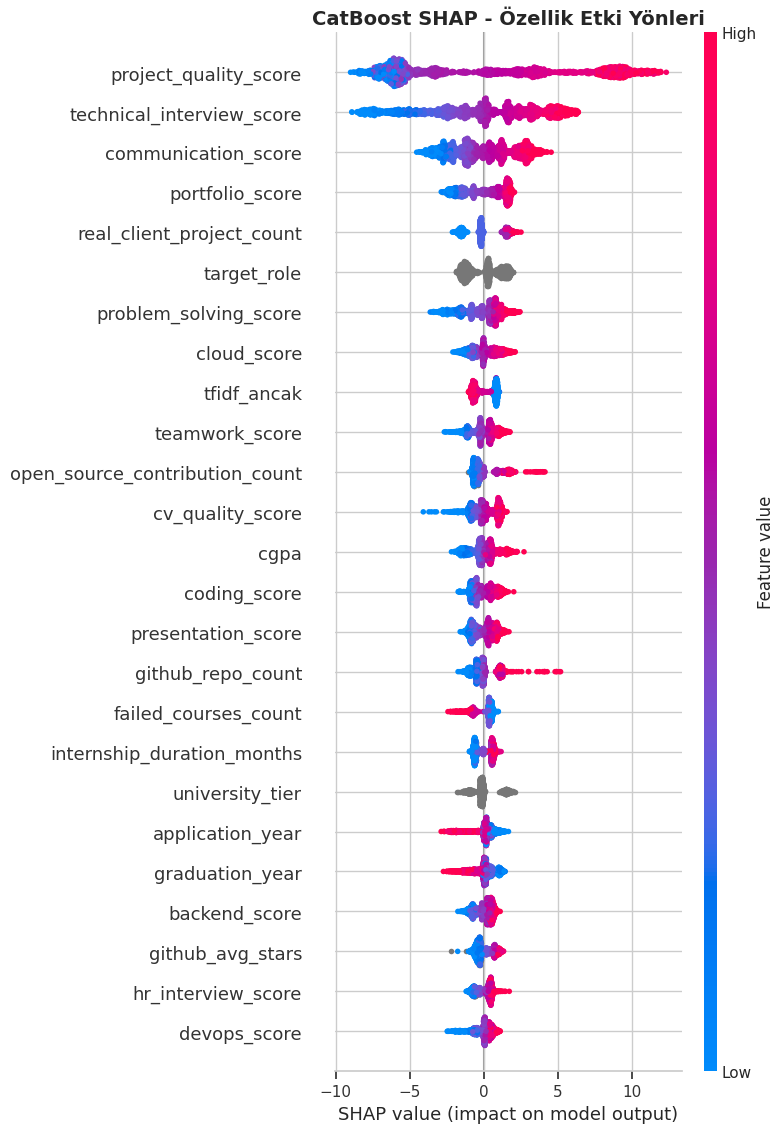

In [77]:
import shap
import matplotlib.pyplot as plt

print("SHAP hesaplanıyor...")

# ---> KRİTİK DÜZELTME: Sadece modelin bildiği özellikleri filtreliyoruz <---
# Bu işlem, araya sızan 'mentor_feedback_text' gibi metinleri veya SVD'leri otomatik atar.
X_shap = X_va_cb[cb_model.feature_names_]

# Explainer'ı oluştur ve SHAP değerlerini hesapla
explainer = shap.TreeExplainer(cb_model)
shap_values = explainer.shap_values(X_shap)

# Görselleştirme
plt.figure(figsize=(10, 8))
plt.title("CatBoost SHAP - Özellik Etki Yönleri", fontweight='bold', fontsize=14)
shap.summary_plot(shap_values, X_shap, max_display=25, show=False)
plt.tight_layout()
plt.show()

## 9. TabPFN SHAP

In [78]:
!pip install shapiq


SHAP değerleri hesaplanıyor...


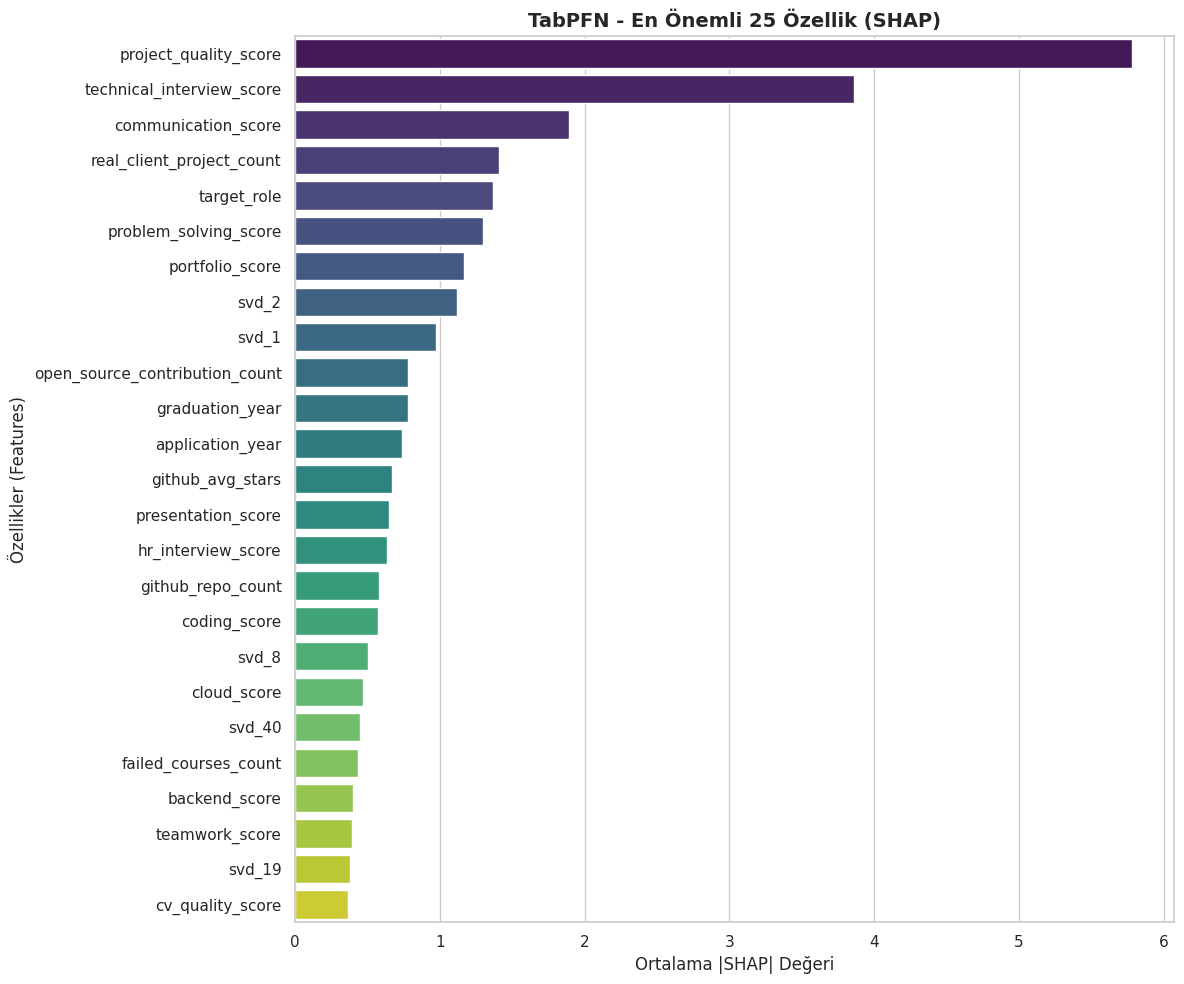

▶ Modelin En Çok Güvendiği İlk 5 Özellik:
                  Feature  Importance
    project_quality_score    5.780245
technical_interview_score    3.861920
      communication_score    1.889999
real_client_project_count    1.410506
              target_role    1.365176


In [79]:
from tabpfn_extensions.interpretability.shapiq import get_tabpfn_imputation_explainer
from tabpfn_extensions.interpretability.shap import shapiq_to_shap_explanation
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# TabPFN'in gördüğü feature listesi (tfidf_cols çıkarılmış)
features_tabpfn = [f for f in X_enc.columns if f not in tfidf_cols]

# Son fold'daki TabPFN train/val verileri
X_tr_tab_last = X_enc.iloc[train_idx].drop(columns=tfidf_cols)
X_va_tab_last = X_enc.iloc[val_idx].drop(columns=tfidf_cols)

print("SHAP değerleri hesaplanıyor...")
explainer = get_tabpfn_imputation_explainer(
    model=tp_model,
    data=X_tr_tab_last.values,
    index="SV",
    max_order=1,
)

shap_exp = shapiq_to_shap_explanation(
    explainer=explainer,
    X=X_va_tab_last.values[:100],
    budget=512,
    feature_names=features_tabpfn,
)

importance_df = pd.DataFrame({
    'Feature': features_tabpfn,
    'Importance': np.abs(shap_exp.values).mean(axis=0)
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(12, 10))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(25), palette='viridis')
plt.title('TabPFN - En Önemli 25 Özellik (SHAP)', fontweight='bold', fontsize=14)
plt.xlabel('Ortalama |SHAP| Değeri')
plt.ylabel('Özellikler (Features)')
plt.tight_layout()
plt.show()

print("▶ Modelin En Çok Güvendiği İlk 5 Özellik:")
print(importance_df.head(5).to_string(index=False))

## 10. TabPFN Prediction

In [ ]:
import pandas as pd
import numpy as np

final_tabpfn_preds = np.clip(test_preds_tabpfn, 0, 100)

submission = pd.DataFrame({
    'student_id': test_df['student_id'],
    target: final_tabpfn_preds
})

submission_file_name = f"{OUTPUT_DIR}/submission_tabpfn_only_v5_svd.csv"
submission.to_csv(submission_file_name, index=False)
print(f"TabPFN submission oluşturuldu: {submission_file_name}")

## 11. Catboost + TabPFN Prediction

In [ ]:
import pandas as pd
import numpy as np

final_blended_preds = np.clip(
    (test_preds_catboost * 0.45) + (test_preds_tabpfn * 0.55), 
    0, 100
)

submission = pd.DataFrame({
    'student_id': test_df['student_id'],
    target: final_blended_preds
})

submission_file_name = f"{OUTPUT_DIR}/submission_catboost_tabpfn_blend_v5_tfidf_svd.csv"
submission.to_csv(submission_file_name, index=False)
print(f"Blend submission oluşturuldu: {submission_file_name}")